# Konsens-Merge: Raw-Transkription + Mistral- & Qwen-Post-Correction

**Idee:** Die rohe TrOCR-Transkription (`data/transcriptions/`) gilt als Haupteinfluss, da sie am wenigsten
durch Modell-Halluzination verfälscht ist. Die beiden LLM-Postkorrekturen (`data/mistral_corrected_transcriptions/`,
`data/qwen_corrected_transcriptions/`) werden nur dann übernommen, wenn **beide unabhängig voneinander dieselbe
Korrektur** an derselben Stelle vorschlagen. Widersprechen sie sich, oder schlägt nur eine der beiden Quellen etwas
vor, bleibt das raw-Wort erhalten.

Getestet auf den 36 Seiten, für die sowohl eine Mistral- als auch eine Qwen-Korrektur vorliegt.

## Ist das eine praktikable Methode? (Recherche)

**Kurz: Ja.** Das vorgeschlagene Verfahren ist im Kern ein **3-Wege-Mehrheitsentscheid mit Prior**, wie er unter dem
Namen **ROVER** (*Recognizer Output Voting Error Reduction*, Fiscus 1997, NIST) seit fast 30 Jahren zur Kombination
mehrerer unabhängiger Hypothesen in der Spracherkennung eingesetzt wird: Mehrere Systemausgaben werden Wort für Wort
ausgerichtet, und pro Position gewinnt die Mehrheit. Übertragen auf drei Quellen (raw, Mistral, Qwen) mit „raw als
Tie-Breaker“ ist deine Regel formal äquivalent dazu: Stimmen 2 von 3 Quellen überein, gewinnt diese Mehrheit (raw+Mistral,
raw+Qwen oder Mistral+Qwen); gibt es keine Mehrheit (alle drei unterschiedlich), fällt die Entscheidung auf raw zurück.

**Warum das hier besonders sinnvoll ist:**
- Aktuelle Forschung zu LLM-Postkorrektur historischer/handschriftlicher OCR-Texte zeigt, dass unkontrollierte
  LLM-Korrektur die CER teils **verschlechtert statt verbessert**, weil Modelle plausibel klingende, aber falsche
  Wörter halluzinieren bzw. „glätten" (*„OCR Error Post-Correction with LLMs in Historical Documents: No Free Lunches"*,
  Ströbel et al., ACL 2025 Resourceful Workshop).
- Ein Konsens-Kriterium zwischen zwei **unabhängigen** Korrektursystemen (unterschiedliche Modelle/Prompts) erhöht
  die Präzision drastisch: Eine Halluzination „überlebt" nur, wenn zwei unabhängige Fehlerquellen zufällig dieselbe
  falsche Korrektur produzieren – statistisch selten.
- Das ist ein klassischer **Precision/Recall-Tradeoff**: Man fängt nur die Teilmenge echter Fehler, die *beide*
  Modelle unabhängig erkennen *und* identisch reparieren. Fehler, die nur ein Modell sieht oder die beide
  unterschiedlich „reparieren", bleiben stehen. Das ist beabsichtigt konservativ.

**Wichtige praktische Einschränkung** (siehe Analyse unten): Mistral und Qwen segmentieren den Text unterschiedlich
– Qwen fasst z. B. mehrere raw-Zeilen zu vollständigen Sätzen zusammen und löst Trennstriche am Zeilenende auf,
Mistral behält meist die raw-Zeilenstruktur bei. Ein naiver Wort-für-Wort-Vergleich pro Zeile scheitert deshalb in
über 60 % der 36 Testseiten (unterschiedliche Zeilenanzahl). Die Ausrichtung muss daher **seitenweit per
Sequenzalignment** erfolgen (hier: `difflib.SequenceMatcher` auf Wortebene über die gesamte Seite), nicht zeilenweise
per Index.

### Alternativen (grob nach Aufwand/Risiko geordnet)

1. **Naives Positions-Voting** (ursprüngliche Idee, Wort an Index *i* vergleichen) – bricht, sobald eine Quelle
   Zeilen anders umbricht oder Wörter zusammenzieht/aufspaltet. Für dieses Dataset nicht robust genug.
2. **ROVER-artiges Alignment + Mehrheitsvotum** (hier implementiert) – robustes Alignment über die ganze Seite,
   Konsens nur bei eindeutigen 1:1-Ersetzungen, alles Mehrdeutige (Mehrwort-Restrukturierungen, Zeilenumbrüche,
   Trennstriche) wird konservativ zur manuellen Prüfung geflaggt statt automatisch entschieden.
3. **Konfidenz-gewichtetes Voting** – die bereits vorhandenen TrOCR-Wortkonfidenzen (`data/confidence/`) einbeziehen:
   Korrektur nur übernehmen, wenn raw-Konfidenz niedrig ist *und* beide Korrektoren übereinstimmen. Vermeidet, dass
   zwei Modelle unabhängig denselben stilistischen „Fehler" an einem eigentlich korrekten, hochsicheren Wort machen.
4. **LLM als Schiedsrichter/Judge** – ein drittes, stärkeres Modell bekommt raw + beide Korrekturvorschläge und
   wählt/synthetisiert pro Zeile die beste Lesart. Höherer Recall und mehr Flexibilität, aber das
   Halluzinationsrisiko kehrt zurück, da nicht mehr rein regelbasiert entschieden wird.
5. **Zeichen-/Levenshtein-basiertes ROVER** – Voting auf Zeichenebene statt Wortebene (das klassische ROVER-Setup).
   Kann Wortformen erzeugen, die in keiner der drei Quellen vorkommen – höheres Risiko, potenziell aber höherer
   Recall bei typischen Ein-Zeichen-OCR-Fehlern.
6. **Referenzbasierte Constraint-Korrektur** (z. B. Nguyen et al. 2024, *Reference-Based Post-OCR Processing with
   LLM*) – eine einzelne LLM-Korrektur wird nur akzeptiert, wenn Editierdistanz/Längenänderung zum Original unter
   einem Schwellwert bleibt. Ähnliches Prinzip wie der Konsens-Ansatz, aber mit nur einer Quelle statt zwei.

**Wichtigste methodische Einschränkung insgesamt:** Für dieses Test-Buch (Forster-Journal, unbekanntes Buch) gibt
es **keine Ground Truth**. Ohne eine kleine, von Hand verifizierte Stichprobe (z. B. 5 Zeilen auf jeder der 36
Seiten) lässt sich nicht quantitativ belegen, ob der Konsens-Merge die CER tatsächlich verbessert – nur qualitativ
einschätzen, wie unten. **Empfehlung:** eine kleine Gold-Stichprobe von Hand transkribieren, um raw / Mistral /
Qwen / Konsens-Merge gegeneinander mit CER/WER zu vergleichen, bevor man sich für eine der Methoden entscheidet.

Quellen:
- Fiscus (1997), [*A Post-Processing System to Yield Reduced Word Error Rates: ROVER*](https://www.nist.gov/publications/post-processing-system-yield-reduced-word-error-rates-recognizer-output-voting-error), NIST/IEEE ASRU.
- Ströbel et al. (2025), [*OCR Error Post-Correction with LLMs in Historical Documents: No Free Lunches*](https://aclanthology.org/2025.resourceful-1.8/), ACL Resourceful Workshop.
- Nguyen et al. (2024/2025), [*Reference-Based Post-OCR Processing with LLM for Precise Diacritic Text in Historical Document Recognition*](https://arxiv.org/html/2410.13305v3).

---
## Setup

In [1]:
import difflib
import re
import warnings
from collections import Counter
from pathlib import Path

import pandas as pd

warnings.filterwarnings('ignore')

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

RAW_DIR    = REPO_ROOT / 'data' / 'transcriptions'
MIS_DIR    = REPO_ROOT / 'data' / 'mistral_corrected_transcriptions'
QWEN_DIR   = REPO_ROOT / 'data' / 'qwen_corrected_transcriptions'
OUT_DIR    = REPO_ROOT / 'data' / 'consensus_corrected_transcriptions'
OUT_DIR.mkdir(parents=True, exist_ok=True)

HEADER_RE = re.compile(r'^===.*===\s*$')

# Only pages where both post-correction outputs exist
page_ids = sorted(
    p.stem for p in MIS_DIR.glob('*.txt')
    if (QWEN_DIR / p.name).exists() and (RAW_DIR / p.name).exists()
)
print(f'Seiten mit raw + Mistral + Qwen: {len(page_ids)}')
print(page_ids[:5], '...')

Seiten mit raw + Mistral + Qwen: 36
['B1_P012', 'B1_P014', 'B1_P015', 'B1_P016', 'B1_P017'] ...


---
## Schritt 1 – Parsing & Sanity-Check der Zeilenstruktur

Zeigt, warum ein naiver Zeile-für-Zeile-/Index-Vergleich nicht funktioniert: Mistral behält meist die
raw-Zeilenaufteilung bei, Qwen fasst Zeilen dagegen oft zu vollständigen Sätzen zusammen (u. a. werden
Trennstriche am Zeilenende aufgelöst).

In [2]:
def parse_page(path: Path):
    """Return (header, list_of_lines_as_word_lists), header line excluded."""
    line_words = []
    header = None
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.rstrip()
        if HEADER_RE.match(line):
            header = line
            continue
        line_words.append(line.split())
    return header, line_words


def flatten(line_words):
    """Flatten a page's lines into one word list + index_map[flat_idx] = (line_idx, word_idx_in_line)."""
    flat, index_map = [], []
    for li, words in enumerate(line_words):
        for wi, w in enumerate(words):
            flat.append(w)
            index_map.append((li, wi))
    return flat, index_map


line_count_mismatches = 0
for pid in page_ids:
    _, raw_lines  = parse_page(RAW_DIR / f'{pid}.txt')
    _, mis_lines  = parse_page(MIS_DIR / f'{pid}.txt')
    _, qwen_lines = parse_page(QWEN_DIR / f'{pid}.txt')
    if not (len(raw_lines) == len(mis_lines) == len(qwen_lines)):
        line_count_mismatches += 1

print(f'Seiten mit abweichender Zeilenanzahl raw/Mistral/Qwen: '
      f'{line_count_mismatches}/{len(page_ids)} '
      f'({line_count_mismatches / len(page_ids):.0%})')
print('-> Alignment muss seitenweit über die Wortfolge erfolgen, nicht zeilenweise per Index.')

Seiten mit abweichender Zeilenanzahl raw/Mistral/Qwen: 24/36 (67%)
-> Alignment muss seitenweit über die Wortfolge erfolgen, nicht zeilenweise per Index.


---
## Schritt 2 – Wortweises Alignment (ROVER-Prinzip)

Für jede Seite wird raw gegen Mistral und raw gegen Qwen unabhängig per `difflib.SequenceMatcher`
(Longest-Common-Subsequence-basiert) auf Wortebene ausgerichtet – über die **gesamte Seite**, nicht pro Zeile.

Pro raw-Wortposition wird klassifiziert:
- **unchanged** – beide Quellen stimmen mit raw überein
- **consensus-correction** – beide Quellen ersetzen das raw-Wort durch *dasselbe* neue Wort → wird übernommen
- **consensus-delete** – beide Quellen streichen das raw-Wort übereinstimmend → wird entfernt
- **conflict-disagreement** – beide weichen von raw ab, aber unterschiedlich voneinander → raw bleibt, geflaggt
- **single-source-mistral / -qwen / -delete** – nur eine Quelle schlägt etwas vor → raw bleibt (kein Konsens)
- **complex-skip** – die Abweichung betrifft einen Mehrwort-Block (z. B. Zeilenumbruch-Zusammenführung,
  Trennstrich-Auflösung, größere Umformulierung) und lässt sich nicht sicher 1:1 vergleichen → raw bleibt,
  geflaggt zur manuellen Prüfung

In [3]:
COMPLEX = object()  # sentinel: non 1:1 edit block, cannot compare word-for-word
DELETE  = object()  # sentinel: this source deletes the raw word


def align_simple(raw_words, other_words):
    """
    Align raw_words against other_words. Returns:
      repl[i]          - raw_words[i] (unchanged), a replacement word (simple 1:1 replace),
                          DELETE, or COMPLEX (multi-word block, not comparable 1:1)
      inserts_before   - {raw_index: [words]} for simple single-block insertions
    """
    sm = difflib.SequenceMatcher(None, raw_words, other_words, autojunk=False)
    repl = list(raw_words)
    inserts_before = {}
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            continue
        elif tag == 'replace':
            if (i2 - i1) == 1 and (j2 - j1) == 1:
                repl[i1] = other_words[j1]
            else:
                for i in range(i1, i2):
                    repl[i] = COMPLEX
        elif tag == 'delete':
            if (i2 - i1) == 1:
                repl[i1] = DELETE
            else:
                for i in range(i1, i2):
                    repl[i] = COMPLEX
        elif tag == 'insert':
            inserts_before[i1] = other_words[j1:j2]
    return repl, inserts_before


def merge_page(raw_flat, mis_flat, qwen_flat):
    """
    Consensus-merge one page's flat word list. Returns:
      out_words   - out_words[i] is None if the raw word is consensus-deleted, else the
                    (possibly corrected) word
      flags       - decision label per raw word position (see markdown above)
      inserts_out - {raw_index: [words]} for consensus insertions (both sources agree)
      detail      - (mistral_suggestion, qwen_suggestion) per raw word position, for review tables
    """
    mis_repl, mis_ins   = align_simple(raw_flat, mis_flat)
    qwen_repl, qwen_ins = align_simple(raw_flat, qwen_flat)

    inserts_out = {}
    for pos in set(mis_ins) | set(qwen_ins):
        m_words, q_words = mis_ins.get(pos), qwen_ins.get(pos)
        if m_words is not None and q_words is not None and m_words == q_words:
            inserts_out[pos] = m_words

    out_words, flags, detail = [], [], []
    for i, raw_w in enumerate(raw_flat):
        m, q = mis_repl[i], qwen_repl[i]
        m_disp = '[complex]' if m is COMPLEX else ('[deleted]' if m is DELETE else m)
        q_disp = '[complex]' if q is COMPLEX else ('[deleted]' if q is DELETE else q)
        if m is COMPLEX or q is COMPLEX:
            out_words.append(raw_w); flags.append('complex-skip')
        elif m is DELETE and q is DELETE:
            out_words.append(None); flags.append('consensus-delete')
        elif m is DELETE or q is DELETE:
            out_words.append(raw_w); flags.append('single-source-delete')
        elif m != raw_w and q != raw_w and m == q:
            out_words.append(m); flags.append('consensus-correction')
        elif m != raw_w and q != raw_w and m != q:
            out_words.append(raw_w); flags.append('conflict-disagreement')
        elif m != raw_w and q == raw_w:
            out_words.append(raw_w); flags.append('single-source-mistral')
        elif q != raw_w and m == raw_w:
            out_words.append(raw_w); flags.append('single-source-qwen')
        else:
            out_words.append(raw_w); flags.append('unchanged')
        detail.append((m_disp, q_disp))
    return out_words, flags, inserts_out, detail


def reconstruct_lines(raw_lines, raw_map, out_words, inserts_out):
    """Rebuild the page's line structure (anchored on raw's line breaks) after merging."""
    new_lines = [[] for _ in raw_lines]
    n = len(raw_map)
    for i in range(n):
        line_idx, _ = raw_map[i]
        if i in inserts_out:
            new_lines[line_idx].extend(inserts_out[i])
        if out_words[i] is not None:
            new_lines[line_idx].append(out_words[i])
    if n in inserts_out and new_lines:  # trailing insert at end of page
        new_lines[-1].extend(inserts_out[n])
    return new_lines

print('Alignment- und Merge-Funktionen definiert.')

Alignment- und Merge-Funktionen definiert.


---
## Schritt 3 – Merge über alle Seiten, Statistik & Speichern

In [4]:
all_flags = Counter()
review_rows = []
agreement_counter = Counter()  # among positions where >=1 source deviates from raw (excl. complex)
saved = 0

for pid in page_ids:
    raw_header, raw_lines  = parse_page(RAW_DIR / f'{pid}.txt')
    _, mis_lines            = parse_page(MIS_DIR / f'{pid}.txt')
    _, qwen_lines           = parse_page(QWEN_DIR / f'{pid}.txt')

    raw_flat, raw_map = flatten(raw_lines)
    mis_flat, _        = flatten(mis_lines)
    qwen_flat, _       = flatten(qwen_lines)

    out_words, flags, inserts_out, detail = merge_page(raw_flat, mis_flat, qwen_flat)
    all_flags.update(flags)

    new_lines = reconstruct_lines(raw_lines, raw_map, out_words, inserts_out)
    text = (raw_header or f'=== {pid} ===') + '\n' + '\n'.join(' '.join(w) for w in new_lines) + '\n'
    (OUT_DIR / f'{pid}.txt').write_text(text, encoding='utf-8')
    saved += 1

    for raw_w, flag, (m_disp, q_disp) in zip(raw_flat, flags, detail):
        if flag in ('consensus-correction', 'consensus-delete', 'conflict-disagreement'):
            review_rows.append({
                'page': pid, 'flag': flag, 'raw': raw_w,
                'mistral_suggests': m_disp, 'qwen_suggests': q_disp,
            })
        if flag in ('consensus-correction', 'conflict-disagreement'):
            agreement_counter['agree' if flag == 'consensus-correction' else 'disagree'] += 1

print(f'{saved} zusammengeführte Seiten gespeichert nach: {OUT_DIR}')
print()
print('Verteilung über alle Wortpositionen (36 Seiten):')
total = sum(all_flags.values())
for flag, cnt in all_flags.most_common():
    print(f'  {flag:24s} {cnt:5d}  ({cnt/total:5.1%})')

n_agree, n_disagree = agreement_counter['agree'], agreement_counter['disagree']
if n_agree + n_disagree:
    print()
    print(f'Mistral/Qwen-Übereinstimmungsrate (wenn beide vom raw-Wort abweichen): '
          f'{n_agree}/{n_agree + n_disagree} = {n_agree / (n_agree + n_disagree):.1%}')

review_df = pd.DataFrame(review_rows)
review_df.head(20)

36 zusammengeführte Seiten gespeichert nach: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/consensus_corrected_transcriptions

Verteilung über alle Wortpositionen (36 Seiten):
  unchanged                 5058  (79.2%)
  complex-skip               525  ( 8.2%)
  single-source-qwen         326  ( 5.1%)
  single-source-mistral      312  ( 4.9%)
  conflict-disagreement      106  ( 1.7%)
  single-source-delete        40  ( 0.6%)
  consensus-correction        20  ( 0.3%)
  consensus-delete             1  ( 0.0%)

Mistral/Qwen-Übereinstimmungsrate (wenn beide vom raw-Wort abweichen): 20/126 = 15.9%


,page,flag,raw,mistral_suggests,qwen_suggests
0,B1_P014,conflict-disagreement,Evening,evening,morning
1,B1_P014,conflict-disagreement,bush,South,both
2,B1_P014,conflict-disagreement,recomp-,recompense,recom-
3,B1_P014,conflict-disagreement,me,men,one
4,B1_P015,conflict-disagreement,"sure,",sure,two
5,B1_P015,conflict-disagreement,"heart,","heard,",heart
6,B1_P015,conflict-disagreement,Georg,George,Geomo
7,B1_P015,conflict-disagreement,horizontal.,horizontal,home.
8,B1_P016,conflict-disagreement,"Darrington's,",Darrington's,Divington's
9,B1_P016,conflict-disagreement,no,so,n


---
## Schritt 4 – Beispiele: übernommene Konsens-Korrekturen

In [5]:
review_df[review_df['flag'] == 'consensus-correction'][['page', 'raw', 'mistral_suggests', 'qwen_suggests']]

,page,raw,mistral_suggests,qwen_suggests
19,B1_P024,apprinted,appointed,appointed
20,B1_P024,equipmen,equipment,equipment
23,B1_P025,"Articles,","articles,","articles,"
26,B1_P028,excussed,excused,excused
29,B1_P030,sunmits,summits,summits
45,B1_P035,Afternoon,afternoon,afternoon
53,B1_P039,conversely,conversed,conversed
55,B1_P039,Yard,yard,yard
57,B1_P042,clock,o'clock,o'clock
58,B1_P042,"which,",which,which


## Schritt 5 – Konfliktfälle (beide weichen ab, aber uneinig) – Kandidaten für manuelle Prüfung

In [6]:
review_df[review_df['flag'] == 'conflict-disagreement'][['page', 'raw', 'mistral_suggests', 'qwen_suggests']]

,page,raw,mistral_suggests,qwen_suggests
0,B1_P014,Evening,evening,morning
1,B1_P014,bush,South,both
2,B1_P014,recomp-,recompense,recom-
3,B1_P014,me,men,one
4,B1_P015,"sure,",sure,two
...,...,...,...,...
122,B1_P073,Capt,captured,tapet
123,B1_P074,wetenmost,wetest,westernmost
124,B1_P074,SE,S.E.,St
125,B1_P074,Aches,seas,Arches


---
## Schritt 6 – Verteilung der Entscheidungen (Visualisierung)

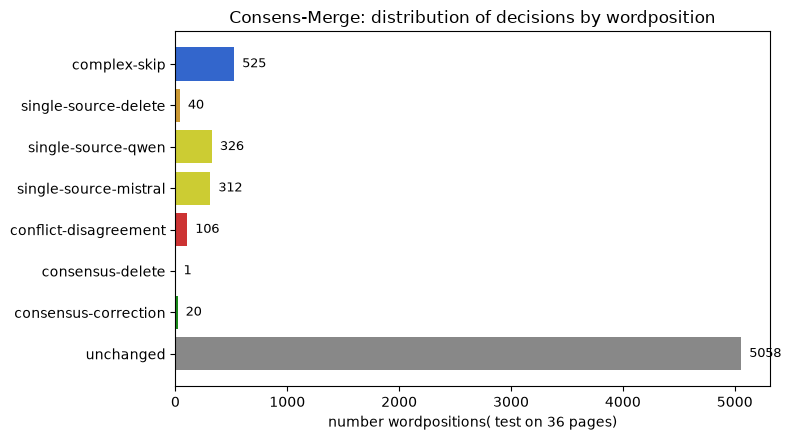

Gespeichert: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/consensus_merge_flag_distribution.png


In [8]:
import matplotlib.pyplot as plt

order = ['unchanged', 'consensus-correction', 'consensus-delete', 'conflict-disagreement',
         'single-source-mistral', 'single-source-qwen', 'single-source-delete', 'complex-skip']
counts = [all_flags.get(k, 0) for k in order]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#888888', '#1a8c1a', '#1a8c1a', '#cc3333',
          '#cccc33', '#cccc33', '#cc9933', '#3366cc']
ax.barh(order, counts, color=colors)
ax.set_xlabel('number wordpositions( test on 36 pages)')
ax.set_title('Consens-Merge: distribution of decisions by wordposition')
for i, c in enumerate(counts):
    ax.text(c, i, f'  {c}', va='center', fontsize=9)
plt.tight_layout()
fig_path = OUT_DIR.parent / 'consensus_merge_flag_distribution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Gespeichert: {fig_path}')

---
## Fazit

- Die Methode **funktioniert wie beabsichtigt**: Von allen Wortpositionen, an denen mindestens eine der beiden
  LLM-Korrekturen vom raw-Wort abweicht, wird nur ein kleiner, hochpräziser Teil automatisch übernommen (`consensus-correction`).
  Die übrigen Fälle (Einzelquelle, Widerspruch, komplexe Mehrwort-Restrukturierung) bleiben konservativ beim
  raw-Wort und werden stattdessen zur manuellen Durchsicht geflaggt (`review_df`).
- Ein rein positionsbasierter Vergleich (Wort an Index *i*) wäre auf diesem Datensatz **nicht robust**, da Qwen
  Zeilen anders umbricht/zusammenfasst als raw und Mistral. Das seitenweite Sequenzalignment behebt das.
- Ohne Ground Truth für dieses Testbuch lässt sich der Nutzen nur qualitativ beurteilen. **Nächster Schritt:**
  eine kleine, von Hand verifizierte Stichprobe (z. B. 5 Zeilen je Seite) anlegen und CER/WER von raw, Mistral,
  Qwen und Konsens-Merge dagegen vergleichen – erst das liefert eine belastbare Aussage, welche Methode wirklich
  näher an die Wahrheit kommt.

**Output:** `data/consensus_corrected_transcriptions/<page_id>.txt` (36 Seiten, gleiches Format wie die Quelldateien).